# TP 1: LDA/QDA y optimización matemática de modelos

# Intro teórica

## Definición: Clasificador Bayesiano

Sean $k$ poblaciones, $x \in \mathbb{R}^p$ puede pertenecer a cualquiera $g \in \mathcal{G}$ de ellas. Bajo un esquema bayesiano, se define entonces $\pi_j \doteq P(G = j)$ la probabilidad *a priori* de que $X$ pertenezca a la clase *j*, y se **asume conocida** la distribución condicional de cada observable dado su clase $f_j \doteq f_{X|G=j}$.

De esta manera dicha probabilidad *a posteriori* resulta
$$
P(G|_{X=x} = j) = \frac{f_{X|G=j}(x) \cdot p_G(j)}{f_X(x)} \propto f_j(x) \cdot \pi_j
$$

La regla de decisión de Bayes es entonces
$$
H(x) \doteq \arg \max_{g \in \mathcal{G}} \{ P(G|_{X=x} = j) \} = \arg \max_{g \in \mathcal{G}} \{ f_j(x) \cdot \pi_j \}
$$

es decir, se predice a $x$ como perteneciente a la población $j$ cuya probabilidad a posteriori es máxima.

*Ojo, a no desesperar! $\pi_j$ no es otra cosa que una constante prefijada, y $f_j$ es, en su esencia, un campo escalar de $x$ a simplemente evaluar.*

## Distribución condicional

Para los clasificadores de discriminante cuadrático y lineal (QDA/LDA) se asume que $X|_{G=j} \sim \mathcal{N}_p(\mu_j, \Sigma_j)$, es decir, se asume que cada población sigue una distribución normal.

Por definición, se tiene entonces que para una clase $j$:
$$
f_j(x) = \frac{1}{(2 \pi)^\frac{p}{2} \cdot |\Sigma_j|^\frac{1}{2}} e^{- \frac{1}{2}(x-\mu_j)^T \Sigma_j^{-1} (x- \mu_j)}
$$

Aplicando logaritmo (que al ser una función estrictamente creciente no afecta el cálculo de máximos/mínimos), queda algo mucho más práctico de trabajar:

$$
\log{f_j(x)} = -\frac{1}{2}\log |\Sigma_j| - \frac{1}{2} (x-\mu_j)^T \Sigma_j^{-1} (x- \mu_j) + C
$$

Observar que en este caso $C=-\frac{p}{2} \log(2\pi)$, pero no se tiene en cuenta ya que al tener una constante aditiva en todas las clases, no afecta al cálculo del máximo.

## LDA

En el caso de LDA se hace una suposición extra, que es $X|_{G=j} \sim \mathcal{N}_p(\mu_j, \Sigma)$, es decir que las poblaciones no solo siguen una distribución normal sino que son de igual matriz de covarianzas. Reemplazando arriba se obtiene entonces:

$$
\log{f_j(x)} =  -\frac{1}{2}\log |\Sigma| - \frac{1}{2} (x-\mu_j)^T \Sigma^{-1} (x- \mu_j) + C
$$

Ahora, como $-\frac{1}{2}\log |\Sigma|$ es común a todas las clases se puede incorporar a la constante aditiva y, distribuyendo y reagrupando términos sobre $(x-\mu_j)^T \Sigma^{-1} (x- \mu_j)$ se obtiene finalmente:

$$
\log{f_j(x)} =  \mu_j^T \Sigma^{-1} (x- \frac{1}{2} \mu_j) + C'
$$

## Entrenamiento/Ajuste

Obsérvese que para ambos modelos, ajustarlos a los datos implica estimar los parámetros $(\mu_j, \Sigma_j) \; \forall j = 1, \dots, k$ en el caso de QDA, y $(\mu_j, \Sigma)$ para LDA.

Estos parámetros se estiman por máxima verosimilitud, de manera que los estimadores resultan:

* $\hat{\mu}_j = \bar{x}_j$ el promedio de los $x$ de la clase *j*
* $\hat{\Sigma}_j = s^2_j$ la matriz de covarianzas estimada para cada clase *j*
* $\hat{\pi}_j = f_{R_j} = \frac{n_j}{n}$ la frecuencia relativa de la clase *j* en la muestra
* $\hat{\Sigma} = \frac{1}{n} \sum_{j=1}^k n_j \cdot s^2_j$ el promedio ponderado (por frecs. relativas) de las matrices de covarianzas de todas las clases. *Observar que se utiliza el estimador de MV y no el insesgado*

Es importante notar que si bien todos los $\mu, \Sigma$ deben ser estimados, la distribución *a priori* puede no inferirse de los datos sino asumirse previamente, utilizándose como entrada del modelo.

## Predicción

Para estos modelos, al igual que para cualquier clasificador Bayesiano del tipo antes visto, la estimación de la clase es por método *plug-in* sobre la regla de decisión $H(x)$, es decir devolver la clase que maximiza $\hat{f}_j(x) \cdot \hat{\pi}_j$, o lo que es lo mismo $\log\hat{f}_j(x) + \log\hat{\pi}_j$.

In [2]:
import numpy as np
import pandas as pd
import numpy.linalg as LA
from scipy.linalg import cholesky, solve_triangular
from scipy.linalg.lapack import dtrtri

In [3]:
from plot import plot_benchmark_results
import matplotlib.pyplot as plt

## Base code

In [4]:
class BaseBayesianClassifier:
  def __init__(self):
    pass

  def _estimate_a_priori(self, y):
    a_priori = np.bincount(y.flatten().astype(int)) / y.size
    # Q3: para que sirve bincount?
    return np.log(a_priori)

  def _fit_params(self, X, y):
    # estimate all needed parameters for given model
    raise NotImplementedError()

  def _predict_log_conditional(self, x, class_idx):
    # predict the log(P(x|G=class_idx)), the log of the conditional probability of x given the class
    # this should depend on the model used
    raise NotImplementedError()

  def fit(self, X, y, a_priori=None):
    # if it's needed, estimate a priori probabilities
    self.log_a_priori = self._estimate_a_priori(y) if a_priori is None else np.log(a_priori)

    # now that everything else is in place, estimate all needed parameters for given model
    self._fit_params(X, y)
    # Q4: por que el _fit_params va al final? no se puede mover a, por ejemplo, antes de la priori?

  def predict(self, X):
    # this is actually an individual prediction encased in a for-loop
    m_obs = X.shape[1]
    y_hat = np.empty(m_obs, dtype=int)

    for i in range(m_obs):
      y_hat[i] = self._predict_one(X[:,i].reshape(-1,1))

    # return prediction as a row vector (matching y)
    return y_hat.reshape(1,-1)

  def _predict_one(self, x):
    # calculate all log posteriori probabilities (actually, +C)
    log_posteriori = [ log_a_priori_i + self._predict_log_conditional(x, idx) for idx, log_a_priori_i
                  in enumerate(self.log_a_priori) ]

    # return the class that has maximum a posteriori probability
    return np.argmax(log_posteriori)

In [5]:
class QDA(BaseBayesianClassifier):

  def _fit_params(self, X, y):
    # estimate each covariance matrix
    self.inv_covs = [LA.inv(np.cov(X[:,y.flatten()==idx], bias=True))
                      for idx in range(len(self.log_a_priori))]
    # Q5: por que hace falta el flatten y no se puede directamente X[:,y==idx]?
    # Q6: por que se usa bias=True en vez del default bias=False?
    self.means = [X[:,y.flatten()==idx].mean(axis=1, keepdims=True)
                  for idx in range(len(self.log_a_priori))]
    # Q7: que hace axis=1? por que no axis=0?

  def _predict_log_conditional(self, x, class_idx):
    # predict the log(P(x|G=class_idx)), the log of the conditional probability of x given the class
    # this should depend on the model used
    inv_cov = self.inv_covs[class_idx]
    unbiased_x =  x - self.means[class_idx]
    return 0.5*np.log(LA.det(inv_cov)) -0.5 * unbiased_x.T @ inv_cov @ unbiased_x

In [6]:
class TensorizedQDA(QDA):

    def _fit_params(self, X, y):
        # ask plain QDA to fit params
        super()._fit_params(X,y)

        # stack onto new dimension
        self.tensor_inv_cov = np.stack(self.inv_covs)
        self.tensor_means = np.stack(self.means)

    def _predict_log_conditionals(self,x):
        unbiased_x = x - self.tensor_means
        inner_prod = unbiased_x.transpose(0,2,1) @ self.tensor_inv_cov @ unbiased_x

        return 0.5*np.log(LA.det(self.tensor_inv_cov)) - 0.5 * inner_prod.flatten()

    def _predict_one(self, x):
        # return the class that has maximum a posteriori probability
        return np.argmax(self.log_a_priori + self._predict_log_conditionals(x))

In [7]:
class QDA_Chol1(BaseBayesianClassifier):
  def _fit_params(self, X, y):
    self.L_invs = [
        LA.inv(cholesky(np.cov(X[:,y.flatten()==idx], bias=True), lower=True))
        for idx in range(len(self.log_a_priori))
    ]

    self.means = [X[:,y.flatten()==idx].mean(axis=1, keepdims=True)
                  for idx in range(len(self.log_a_priori))]

  def _predict_log_conditional(self, x, class_idx):
    L_inv = self.L_invs[class_idx]
    unbiased_x =  x - self.means[class_idx]

    y = L_inv @ unbiased_x

    return np.log(L_inv.diagonal().prod()) -0.5 * (y**2).sum()

In [8]:
class QDA_Chol2(BaseBayesianClassifier):
  def _fit_params(self, X, y):
    self.Ls = [
        cholesky(np.cov(X[:,y.flatten()==idx], bias=True), lower=True)
        for idx in range(len(self.log_a_priori))
    ]

    self.means = [X[:,y.flatten()==idx].mean(axis=1, keepdims=True)
                  for idx in range(len(self.log_a_priori))]

  def _predict_log_conditional(self, x, class_idx):
    L = self.Ls[class_idx]
    unbiased_x =  x - self.means[class_idx]

    y = solve_triangular(L, unbiased_x, lower=True)

    return -np.log(L.diagonal().prod()) -0.5 * (y**2).sum()

In [9]:
class QDA_Chol3(BaseBayesianClassifier):
  def _fit_params(self, X, y):
    self.L_invs = [
        dtrtri(cholesky(np.cov(X[:,y.flatten()==idx], bias=True), lower=True), lower=1)[0]
        for idx in range(len(self.log_a_priori))
    ]

    self.means = [X[:,y.flatten()==idx].mean(axis=1, keepdims=True)
                  for idx in range(len(self.log_a_priori))]

  def _predict_log_conditional(self, x, class_idx):
    L_inv = self.L_invs[class_idx]
    unbiased_x =  x - self.means[class_idx]

    y = L_inv @ unbiased_x

    return np.log(L_inv.diagonal().prod()) -0.5 * (y**2).sum()

## Datasets

Observar que se proveen **4 datasets diferentes**, el código de ejemplo usa uno solo pero eso no significa que ustedes se limiten al mismo. También pueden usar otros datasets de su elección.

In [10]:
from sklearn.datasets import load_iris, fetch_openml, load_wine
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def get_iris_dataset():
  data = load_iris()
  X_full = data.data
  y_full = np.array([data.target_names[y] for y in data.target.reshape(-1,1)])
  return X_full, y_full

def get_penguins_dataset():
    # get data
    df, tgt = fetch_openml(name="penguins", return_X_y=True, as_frame=True, parser='auto')

    # drop non-numeric columns
    df.drop(columns=["island","sex"], inplace=True)

    # drop rows with missing values
    mask = df.isna().sum(axis=1) == 0
    df = df[mask]
    tgt = tgt[mask]

    return df.values, tgt.to_numpy().reshape(-1,1)

def get_wine_dataset():
    # get data
    data = load_wine()
    X_full = data.data
    y_full = np.array([data.target_names[y] for y in data.target.reshape(-1,1)])
    return X_full, y_full

def get_letters_dataset():
    # get data
    letter = fetch_openml('letter', version=1, as_frame=False)
    return letter.data, letter.target.reshape(-1,1)

def label_encode(y_full):
    return LabelEncoder().fit_transform(y_full.flatten()).reshape(y_full.shape)

def split_transpose(X, y, test_size, random_state):
    # X_train, X_test, y_train, y_test but all transposed
    return [elem.T for elem in train_test_split(X, y, test_size=test_size, random_state=random_state)]

## Benchmarking

Nota: esta clase fue creada bastante rápido y no pretende ser una plataforma súper confiable sobre la que basarse, sino más bien una herramienta simple con la que poder medir varios runs y agregar la información.

En forma rápida, `warmup` es la cantidad de runs para warmup, `mem_runs` es la cantidad de runs en las que se mide el pico de uso de RAM y `n_runs` es la cantidad de runs en las que se miden tiempos.

La razón por la que se separan es que medir memoria hace ~2.5x más lento cada run, pero al mismo tiempo se estabiliza mucho más rápido.

**Importante:** tener en cuenta que los modelos que predicen en batch (usan `predict` directamente) deberían consumir, como mínimo, $n$ veces la memoria de los que predicen por observación.

In [11]:
import time
from tqdm.notebook import tqdm
from numpy.random import RandomState
import tracemalloc

RNG_SEED = 6553

class Benchmark:
    def __init__(self, X, y, n_runs=1000, warmup=100, mem_runs=100, test_sz=0.3, rng_seed=RNG_SEED, same_splits=True):
        self.X = X
        self.y = y
        self.n = n_runs
        self.warmup = warmup
        self.mem_runs = mem_runs
        self.test_sz = test_sz
        self.det = same_splits
        if self.det:
            self.rng_seed = rng_seed
        else:
            self.rng = RandomState(rng_seed)

        self.data = dict()

        print("Benching params:")
        print("Total runs:",self.warmup+self.mem_runs+self.n)
        print("Warmup runs:",self.warmup)
        print("Peak Memory usage runs:", self.mem_runs)
        print("Running time runs:", self.n)
        approx_test_sz = int(self.y.size * self.test_sz)
        print("Train size rows (approx):",self.y.size - approx_test_sz)
        print("Test size rows (approx):",approx_test_sz)
        print("Test size fraction:",self.test_sz)

    def bench(self, model_class, **kwargs):
        name = model_class.__name__
        time_data = np.empty((self.n, 3), dtype=float)  # train_time, test_time, accuracy
        mem_data = np.empty((self.mem_runs, 2), dtype=float)  # train_peak_mem, test_peak_mem
        rng = RandomState(self.rng_seed) if self.det else self.rng


        for i in range(self.warmup):
            # Instantiate model with error check for unsupported parameters
            model = model_class(**kwargs)

            # Generate current train-test split
            X_train, X_test, y_train, y_test = split_transpose(
                self.X, self.y,
                test_size=self.test_sz,
                random_state=rng
            )
            # Run training and prediction (timing or memory measurement not recorded)
            model.fit(X_train, y_train)
            model.predict(X_test)

        for i in tqdm(range(self.mem_runs), total=self.mem_runs, desc=f"{name} (MEM)"):

            model = model_class(**kwargs)

            X_train, X_test, y_train, y_test = split_transpose(
                self.X, self.y,
                test_size=self.test_sz,
                random_state=rng
            )

            tracemalloc.start()

            t1 = time.perf_counter()
            model.fit(X_train, y_train)
            t2 = time.perf_counter()

            _, train_peak = tracemalloc.get_traced_memory()
            tracemalloc.reset_peak()

            model.predict(X_test)
            t3 = time.perf_counter()
            _, test_peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            mem_data[i,] = (
                train_peak / (1024 * 1024),
                test_peak / (1024 * 1024)
            )

        for i in tqdm(range(self.n), total=self.n, desc=f"{name} (TIME)"):
            model = model_class(**kwargs)

            X_train, X_test, y_train, y_test = split_transpose(
                self.X, self.y,
                test_size=self.test_sz,
                random_state=rng
            )

            t1 = time.perf_counter()
            model.fit(X_train, y_train)
            t2 = time.perf_counter()
            preds = model.predict(X_test)
            t3 = time.perf_counter()

            time_data[i,] = (
                (t2 - t1) * 1000,
                (t3 - t2) * 1000,
                (y_test.flatten() == preds.flatten()).mean()
            )

        self.data[name] = (time_data, mem_data)

    def summary(self, baseline=None):
        aux = []
        for name, (time_data, mem_data) in self.data.items():
            result = {
                'model': name,
                'train_median_ms': np.median(time_data[:, 0]),
                'train_std_ms': time_data[:, 0].std(),
                'test_median_ms': np.median(time_data[:, 1]),
                'test_std_ms': time_data[:, 1].std(),
                'mean_accuracy': time_data[:, 2].mean(),
                'train_mem_median_mb': np.median(mem_data[:, 0]),
                'train_mem_std_mb': mem_data[:, 0].std(),
                'test_mem_median_mb': np.median(mem_data[:, 1]),
                'test_mem_std_mb': mem_data[:, 1].std()
            }
            aux.append(result)
        df = pd.DataFrame(aux).set_index('model')

        if baseline is not None and baseline in self.data:
            df['train_speedup'] = df.loc[baseline, 'train_median_ms'] / df['train_median_ms']
            df['test_speedup'] = df.loc[baseline, 'test_median_ms'] / df['test_median_ms']
            df['train_mem_reduction'] = df.loc[baseline, 'train_mem_median_mb'] / df['train_mem_median_mb']
            df['test_mem_reduction'] = df.loc[baseline, 'test_mem_median_mb'] / df['test_mem_median_mb']
        return df

In [12]:
# levantamos el dataset Wine, que tiene 13 features y 178 observaciones en total
X_full, y_full = get_wine_dataset()

X_full.shape, y_full.shape

((178, 13), (178, 1))

In [13]:
# encodeamos a número las clases
y_full_encoded = label_encode(y_full)

y_full[:5], y_full_encoded[:5]

(array([['class_0'],
        ['class_0'],
        ['class_0'],
        ['class_0'],
        ['class_0']], dtype='<U7'),
 array([[0],
        [0],
        [0],
        [0],
        [0]]))

In [14]:
# generamos el benchmark
# observar que son valores muy bajos de runs para que corra rápido ahora
b = Benchmark(
    X_full, y_full_encoded,
    n_runs = 100,
    warmup = 20,
    mem_runs = 20,
    test_sz = 0.3,
    same_splits = False
)

Benching params:
Total runs: 140
Warmup runs: 20
Peak Memory usage runs: 20
Running time runs: 100
Train size rows (approx): 125
Test size rows (approx): 53
Test size fraction: 0.3


In [15]:
# bencheamos un par
to_bench = [QDA]

for model in to_bench:
    b.bench(model)

QDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

QDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

In [16]:
# como es una clase, podemos seguir bencheando más después
b.bench(TensorizedQDA)

TensorizedQDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

In [17]:
# hacemos un summary
b.summary()

,train_median_ms,train_std_ms,test_median_ms,test_std_ms,mean_accuracy,train_mem_median_mb,train_mem_std_mb,test_mem_median_mb,test_mem_std_mb
model,,,,,,,,,
QDA,0.211552,0.213972,1.441333,0.608244,0.982407,0.018379,0.000661,0.007552,0.001601
TensorizedQDA,0.202774,0.133050,0.587329,0.322512,0.982593,0.018379,0.000680,0.012016,0.000176


In [18]:
# son muchos datos! nos quedamos con un par nomás
summ = b.summary()

# como es un pandas DataFrame, subseteamos columnas fácil
summ[['train_median_ms', 'test_median_ms','mean_accuracy']]

,train_median_ms,test_median_ms,mean_accuracy
model,,,
QDA,0.211552,1.441333,0.982407
TensorizedQDA,0.202774,0.587329,0.982593


In [19]:
# podemos setear un baseline para que fabrique columnas de comparación
summ = b.summary(baseline='QDA')

summ

,train_median_ms,train_std_ms,test_median_ms,test_std_ms,mean_accuracy,train_mem_median_mb,train_mem_std_mb,test_mem_median_mb,test_mem_std_mb,train_speedup,test_speedup,train_mem_reduction,test_mem_reduction
model,,,,,,,,,,,,,
QDA,0.211552,0.213972,1.441333,0.608244,0.982407,0.018379,0.000661,0.007552,0.001601,1.000000,1.000000,1.0,1.000000
TensorizedQDA,0.202774,0.133050,0.587329,0.322512,0.982593,0.018379,0.000680,0.012016,0.000176,1.043292,2.454046,1.0,0.628492


In [20]:
summ[[
    'train_median_ms', 'test_median_ms','mean_accuracy',
    'train_speedup', 'test_speedup',
    'train_mem_reduction', 'test_mem_reduction'
]]

,train_median_ms,test_median_ms,mean_accuracy,train_speedup,test_speedup,train_mem_reduction,test_mem_reduction
model,,,,,,,
QDA,0.211552,1.441333,0.982407,1.000000,1.000000,1.0,1.000000
TensorizedQDA,0.202774,0.587329,0.982593,1.043292,2.454046,1.0,0.628492


# Consigna QDA

**Notación**: en general notamos

* $k$ la cantidad de clases
* $n$ la cantidad de observaciones
* $p$ la cantidad de features/variables/predictores

**Sugerencia:** combinaciones adecuadas de `transpose`, `stack`, `reshape` y, ocasionalmente, `flatten` y `diagonal` suele ser más que suficiente. Se recomienda *fuertemente* explorar la dimensionalidad de cada elemento antes de implementar las clases.

## Tensorización

En esta sección nos vamos a ocupar de hacer que el modelo sea más rápido para generar predicciones, observando que incurre en un doble `for` dado que predice en forma individual un escalar para cada observación, para cada clase. Paralelizar ambos vía tensorización suena como una gran vía de mejora de tiempos.

### 1) Diferencias entre `QDA` y `TensorizedQDA`

1. ¿Sobre qué paraleliza `TensorizedQDA`? ¿Sobre las $k$ clases, las $n$ observaciones a predecir, o ambas?
2. Analizar los shapes de `tensor_inv_covs` y `tensor_means` y explicar paso a paso cómo es que `TensorizedQDA` llega a predecir lo mismo que `QDA`.

### 2) Optimización

Debido a la forma cuadrática de QDA, no se puede predecir para $n$ observaciones en una sola pasada (utilizar $X \in \mathbb{R}^{p \times n}$ en vez de $x \in \mathbb{R}^p$) sin pasar por una matriz de $n \times n$ en donde se computan todas las interacciones entre observaciones. Se puede acceder al resultado recuperando sólo la diagonal de dicha matriz, pero resulta ineficiente en tiempo y (especialmente) en memoria. Aún así, es *posible* que el modelo funcione más rápido.

3. Implementar el modelo `FasterQDA` (se recomienda heredarlo de `TensorizedQDA`) de manera de eliminar el ciclo for en el método predict.
4. Mostrar dónde aparece la mencionada matriz de $n \times n$, donde $n$ es la cantidad de observaciones a predecir.
5. Demostrar que
$$
diag(A \cdot B) = \sum_{cols} A \odot B^T = np.sum(A \odot B^T, axis=1)
$$ es decir, que se puede "esquivar" la matriz de $n \times n$ usando matrices de $n \times p$. También se puede usar, de forma equivalente,
$$
np.sum(A^T \odot B, axis=0).T
$$
queda a preferencia del alumno cuál usar.
6. Utilizar la propiedad antes demostrada para reimplementar la predicción del modelo `FasterQDA` de forma eficiente en un nuevo modelo `EfficientQDA`.
7. Comparar la performance de las 4 variantes de QDA implementadas hasta ahora (no Cholesky) ¿Qué se observa? A modo de opinión ¿Se condice con lo esperado?

## Cholesky

Hasta ahora todos los esfuerzos fueron enfocados en realizar una predicción más rápida. Los tiempos de entrenamiento (teóricos al menos) siguen siendo los mismos o hasta (minúsculamente) peores, dado que todas las mejoras siguen llamando al método `_fit_params` original de `QDA`.

La descomposición/factorización de [Cholesky](https://en.wikipedia.org/wiki/Cholesky_decomposition#Statement) permite factorizar una matriz definida positiva $A = LL^T$ donde $L$ es una matriz triangular inferior. En particular, si bien se asume que $p \ll n$, invertir la matriz de covarianzas $\Sigma$ para cada clase impone un cuello de botella que podría alivianarse. Teniendo en cuenta que las matrices de covarianza son simétricas y salvo degeneración, definidas positivas, Cholesky como mínimo debería permitir invertir la matriz más rápido.

*Nota: observar que calcular* $A^{-1}b$ *equivale a resolver el sistema* $Ax=b$.

### 3) Diferencias entre implementaciones de `QDA_Chol`

8. Si una matriz $A$ tiene fact. de Cholesky $A=LL^T$, expresar $A^{-1}$ en términos de $L$. ¿Cómo podría esto ser útil en la forma cuadrática de QDA?
7. Explicar las diferencias entre `QDA_Chol1`y `QDA` y cómo `QDA_Chol1` llega, paso a paso, hasta las predicciones.
8. ¿Cuáles son las diferencias entre `QDA_Chol1`, `QDA_Chol2` y `QDA_Chol3`?
9. Comparar la performance de las 7 variantes de QDA implementadas hasta ahora ¿Qué se observa?¿Hay alguna de las implementaciones de `QDA_Chol` que sea claramente mejor que las demás?¿Alguna que sea peor?

### 4) Optimización

12. Implementar el modelo `TensorizedChol` paralelizando sobre clases/observaciones según corresponda. Se recomienda heredarlo de alguna de las implementaciones de `QDA_Chol`, aunque la elección de cuál de ellas queda a cargo del alumno según lo observado en los benchmarks de puntos anteriores.
13. Implementar el modelo `EfficientChol` combinando los insights de `EfficientQDA` y `TensorizedChol`. Si se desea, se puede implementar `FasterChol` como ayuda, pero no se contempla para el punto.
13. Comparar la performance de las 9 variantes de QDA implementadas ¿Qué se observa? A modo de opinión ¿Se condice con lo esperado?

## Importante:

Las métricas que se observan al realizar benchmarking son muy dependientes del código que se ejecuta, y por tanto de las versiones de las librerías utilizadas. Una forma de unificar esto es utilizando un gestor de versiones y paquetes como _uv_ o _Poetry_, otra es simplemente usando una misma VM como la que provee Colab.

**Cada equipo debe informar las versiones de Python, NumPy y SciPy con que fueron obtenidos los resultados. En caso de que sean múltiples, agregar todos los casos**. La siguiente celda provee una ayuda para hacerlo desde un notebook, aunque como es una secuencia de comandos también sirve para consola.

In [21]:
%%bash
python --version
pip freeze | grep -E "scipy|numpy"

Python 3.13.5
numpy @ file:///croot/numpy_and_numpy_base_1730835581507/work/dist/numpy-2.1.3-cp313-cp313-linux_x86_64.whl#sha256=93cc19de59d42f9bf7c3d5ba08393a478655029d2a15deb048523ce617da711c
numpydoc @ file:///io/buildout/croot/numpydoc_1732921012507/work
scipy @ file:///croot/scipy_1747238027288/work/dist/scipy-1.15.3-cp313-cp313-linux_x86_64.whl#sha256=ef0f7946c766acf9935b91f06cb7735ddb4890c85109a813e5ea260749c68c5c


**Comentario:** yo utilicé los siguientes parámetros para mi run de prueba. Esto NO significa que ustedes tengan que usar los mismos, tampoco el mismo dataset. Se agregó al notebook simplemente porque fue una pregunta común en cohortes anteriores.

In [22]:
# dataset de letters
X_letter, y_letter = get_letters_dataset()

# encoding de labels
y_letter_encoded = label_encode(y_letter.reshape(-1,1))

# instanciacion del benchmark
b = Benchmark(
    X_letter, y_letter_encoded,
    same_splits=False,
    n_runs=100,
    warmup=20,
    mem_runs=30,
    test_sz=0.2
)

Benching params:
Total runs: 150
Warmup runs: 20
Peak Memory usage runs: 30
Running time runs: 100
Train size rows (approx): 16000
Test size rows (approx): 4000
Test size fraction: 0.2


## Ejercicio 1: Diferencias entre QDA y TensorizedQDA

### 1.1) ¿Sobre qué paraleliza `TensorizedQDA`?

`TensorizedQDA` paraleliza **únicamente sobre las $k$ clases**, NO sobre las $n$ observaciones a predecir.

En `QDA` básico, el proceso de predicción tiene **dos loops anidados**:
```python
# BaseBayesianClassifier.predict()
for i in range(n):  # Loop sobre observaciones
    x_i = X[:, i]
    # QDA._predict_one()
    for idx in range(k):  # Loop sobre clases
        log_posteriori[idx] = log_a_priori[idx] + _predict_log_conditional(x_i, idx)
    y_hat[i] = argmax(log_posteriori)
```

En `TensorizedQDA`:
- **Elimina:** el loop interno sobre las $k$ clases usando operaciones tensoriales
- **Mantiene:** el loop externo sobre las $n$ observaciones (hereda el método `predict` de `BaseBayesianClassifier` por lo que **sigue iterando sobre cada una de las observaciones**)

```python
# TensorizedQDA sigue usando BaseBayesianClassifier.predict()
for i in range(n):  # Loop sobre observaciones (NO eliminado)
    x_i = X[:, i]
    # TensorizedQDA._predict_one() calcula TODAS las clases en paralelo
    log_posterioris = log_a_priori + _predict_log_conditionals(x_i)  # Vectorizado sobre k
    y_hat[i] = argmax(log_posterioris)
```

### 1.2) Análisis de shapes y proceso de predicción

#### Shapes de los tensores

| Atributo | QDA (listas) | TensorizedQDA (tensores) |
|----------|--------------|--------------------------|
| `inv_covs` / `tensor_inv_cov` | Lista de $k$ matrices $(p \times p)$ | Tensor $(k \times p \times p)$ |
| `means` / `tensor_means` | Lista de $k$ vectores $(p \times 1)$ | Tensor $(k \times p \times 1)$ |

**Creación de tensores en `_fit_params`:**
```python
# Primero entrena como QDA normal (listas)
super()._fit_params(X, y)

# Luego apila las listas en tensores 3D
self.tensor_inv_cov = np.stack(self.inv_covs)  # (k, p, p)
self.tensor_means = np.stack(self.means)        # (k, p, 1)
```

#### Proceso paso a paso de predicción

Para una observación $x \in \mathbb{R}^{p \times 1}$:

**Paso 1: Centrado vectorizado**
```python
# Se resta la media. Hay Broadcasting involucrado ya que x es originalmente una muestra con p features, por lo que el resultado final es de k veces el valor de p -> (p, 1) - (k, p, 1) → (k, p, 1)
unbiased_x = x - self.tensor_means
# Resultado: k vectores centrados simultáneamente
#   unbiased_x[0] = x - μ_0
#   unbiased_x[1] = x - μ_1
#   ...
#   unbiased_x[k-1] = x - μ_{k-1}
```

**Paso 2: Forma cuadrática en batch**
```python
# El tensor unbiased_x se transpone segun la definición de la cuenta.
inner_prod = unbiased_x.transpose(0,2,1) @ self.tensor_inv_cov @ unbiased_x
# (k, 1, p) @ (k, p, p) @ (k, p, 1) → (k, 1, 1)
# Se calcula (x-μ_j)ᵀ Σ_j⁻¹ (x-μ_j) para TODAS las clases simultáneamente
```

**Paso 3: Cálculo del log-condicional donde se calculan los valores restantes para obtener $\log f_j(x)$**
```python
det_term = 0.5 * np.log(LA.det(self.tensor_inv_cov))  # shape: (k)
quad_term = -0.5 * inner_prod.flatten()                # shape: (k)

return det_term + quad_term  # shape: (k) - un valor por clase
```

**Paso 4: Predicción final**
```python
# En _predict_one()
log_posteriori = self.log_a_priori + self._predict_log_conditionals(x)
# (k) + (k) → (k)

return np.argmax(log_posteriori)  # Clase con máxima probabilidad a posteriori
```

#### ¿Por qué llega al mismo resultado que QDA?

**Matemáticamente:**
- Ambos calculan la misma fórmula: $\log f_j(x) = \frac{1}{2}\log|\Sigma_j^{-1}| - \frac{1}{2}(x-\mu_j)^T \Sigma_j^{-1} (x-\mu_j)$
- QDA lo hace clase por clase en un loop mientras que TensorizedQDA lo hace para todas las clases en una sola operación matricial


## Ejercicio 2: Optimización de QDA

### 2.3) Implementación de FasterQDA

In [23]:
class FasterQDA(TensorizedQDA):
    """
    Elimina el loop sobre observaciones en predict.
    Procesa todas las observaciones simultáneamente para todas las clases.
    Genera una matriz intermedia de n x n que es ineficiente en memoria.
    """
    
    def _predict_log_conditionals_sim(self, X):
        """
        Calcula log-condicionales para múltiples observaciones simultáneamente.
        X tiene shape (p, n) donde n es el número de observaciones.
        Retorna un array de shape (k, n) con los log-condicionales.
        """
        # Broadcasting: (p, n) - (k, p, 1) -> (k, p, n)
        unbiased_X = X - self.tensor_means
        
        # Forma cuadrática: (k, n, p) @ (k, p, p) @ (k, p, n) -> (k, n, n)
        # AQUÍ aparece la matriz n x n mencionada en el enunciado ya que en este caso, unbiased_X no es un vector de (p,1) sino q es de (p,n)
        inner_prod = unbiased_X.transpose(0, 2, 1) @ self.tensor_inv_cov @ unbiased_X
        # inner_prod shape: (k, n, n)
        
        # Extraer la diagonal para cada clase: queremos inner_prod[j, i, i] para cada clase j
        # La diagonal nos da (x_i - μ_j)ᵀ Σ_j⁻¹ (x_i - μ_j) para cada observación i y clase j
        quad_form = np.array([np.diag(inner_prod[j]) for j in range(len(self.log_a_priori))])  # (k, n)
        
        # Calcular el término del determinante (igual para todas las observaciones)
        det_term = 0.5 * np.log(LA.det(self.tensor_inv_cov))  # (k,)
        
        # Log-condicional para cada clase y observación
        log_conditionals = det_term[:, np.newaxis] - 0.5 * quad_form  # (k, n)
        
        return log_conditionals
    
    def predict(self, X):
        # X tiene shape (p, n) donde n es el número de observaciones
        
        # Calcular log-condicionales para todas las observaciones simultáneamente
        log_conditionals = self._predict_log_conditionals_sim(X)  # (k, n)
        
        # Log-posterior: agregar log a priori
        log_posteriors = self.log_a_priori[:, np.newaxis] + log_conditionals  # (k, n)
        
        # Argmax sobre clases (axis=0) para obtener la clase predicha de cada observación
        y_hat = np.argmax(log_posteriors, axis=0)  # (n,)
        
        return y_hat.reshape(1, -1)  # (1, n) para coincidir con formato esperado

### 2.4) Matriz n × n en FasterQDA

La matriz de $n \times n$ aparece en la línea:
```python
inner_prod = unbiased_X.transpose(0, 2, 1) @ self.tensor_inv_cov @ unbiased_X
# Shape: (k, n, n)
```

Donde `unbiased_X` tiene shape $(k, p, n)$, entonces:
- `unbiased_X.transpose(0, 2, 1)` → $(k, n, p)$
- `self.tensor_inv_cov` → $(k, p, p)$  
- `unbiased_X` → $(k, p, n)$

El producto matricial resulta: $(k, n, p) \times (k, p, p) \times (k, p, n) \to (k, n, n)$

Esta matriz de $(k, n, n)$ es **muy grande** cuando $n$ (número de observaciones a predecir) es alto, y solo necesitamos su diagonal.


### 2.5) Demostración: Diagonal del producto via Hadamard

**Teorema:** Para matrices $A \in \mathbb{R}^{n \times p}$ y $B \in \mathbb{R}^{p \times n}$ (si bien en este caso las matrices son cuadradas, se puede generalizar):
$$
\text{diag}(A \cdot B) = \sum_{\text{cols}} A \odot B^T = \texttt{np.sum}(A \odot B^T, \texttt{axis=1})
$$

**Demostración:**

**Paso 1: Diagonal del producto matricial**

El producto matricial $C = A \cdot B$ tiene dimensión $n \times n$, donde el elemento $(i,j)$ es:
$$
C_{ij} = (A \cdot B)_{ij} = \sum_{k=1}^{p} A_{ik} B_{kj}
$$

La diagonal de $C$ consiste en los elementos donde $i = j$:
$$
\text{diag}(C)_i = C_{ii} = \sum_{k=1}^{p} A_{ik} B_{ki}
$$

Es decir, para cada fila $i$:
$$
C_{ii} = A_{i1}B_{1i} + A_{i2}B_{2i} + \cdots + A_{ip}B_{pi}
$$

El vector diagonal completo de $C$ se puede expresar como:
$$
\text{diag}(C) = \begin{bmatrix}
C_{11} \\
C_{22} \\
\vdots \\
C_{nn}
\end{bmatrix} = \begin{bmatrix}
A_{11}B_{11} + A_{12}B_{21} + \cdots + A_{1p}B_{p1} \\
A_{21}B_{12} + A_{22}B_{22} + \cdots + A_{2p}B_{p2} \\
\vdots \\
A_{n1}B_{1n} + A_{n2}B_{2n} + \cdots + A_{np}B_{pn}
\end{bmatrix}
$$

**Paso 2: Producto de Hadamard con $B^T$**

El producto de Hadamard $A \odot B^T$ multiplica elemento por elemento. Como $B^T \in \mathbb{R}^{n \times p}$ tiene $(B^T)_{ik} = B_{ki}$, entonces:
$$
(A \odot B^T)_{ik} = A_{ik} \cdot (B^T)_{ik} = A_{ik} \cdot B_{ki}
$$

Para la fila $i$-ésima, tenemos:
$$
\text{fila}_i(A \odot B^T) = [A_{i1}B_{1i}, \; A_{i2}B_{2i}, \; \ldots, \; A_{ip}B_{pi}]
$$

**Paso 3: Suma por columnas (filas)**

Al sumar los elementos de cada fila $i$ (es decir, sumando sobre las columnas con `axis=1`):
$$
\sum_{k=1}^{p} (A \odot B^T)_{ik} = \sum_{k=1}^{p} A_{ik} B_{ki} = A_{i1}B_{1i} + A_{i2}B_{2i} + \cdots + A_{ip}B_{pi}
$$

Comparando con el **Paso 1**, vemos que:
$$
\sum_{k=1}^{p} (A \odot B^T)_{ik} = C_{ii} = \text{diag}(A \cdot B)_i
$$

Por lo tanto:
$$
\text{diag}(A \cdot B) = \sum_{\text{cols}} A \odot B^T \quad 
$$

**Sobre `axis=1` en NumPy:**

En NumPy, `axis=1` significa **sumar a lo largo de las columnas** (dentro de cada fila), reduciendo la dimensión de columnas. Para una matriz de shape $(n, p)$:
- `np.sum(M, axis=0)` → suma cada columna → resultado shape $(p,)$
- `np.sum(M, axis=1)` → suma cada fila → resultado shape $(n,)$

En nuestro caso, `A ⊙ B^T` tiene shape $(n, p)$, y queremos $n$ valores (uno por cada elemento diagonal), entonces usamos `axis=1` para sumar cada una de las $n$ filas.

**Forma alternativa:**

También se puede usar:
$$
\text{diag}(A \cdot B) = \texttt{np.sum}(A^T \odot B, \texttt{axis=0})^T
$$

donde ahora:
- $A^T \odot B$ tiene shape $(p, n)$
- `axis=0` suma cada columna (las $p$ filas) 
- El resultado shape $(n,)$ se transpone (aunque ya es un vector, la transpuesta es conceptual)

Ambas formas son equivalentes, queda a preferencia del implementador.

### 2.6) Implementación EfficientQDA

In [24]:
class EfficientQDA(FasterQDA):
    """
    Versión eficiente que evita crear la matriz n x n.
    Usa la propiedad: diag(A·B) = sum(A ⊙ B^T, axis=1)
    para calcular solo los elementos diagonales que necesitamos.
    """
    
    def _predict_log_conditionals_sim(self, X):
        """
        Calcula log-condicionales para múltiples observaciones de manera eficiente.
        Evita crear la matriz n×n usando la propiedad de Hadamard.
        X tiene shape (p, n) donde n es el número de observaciones.
        Retorna un array de shape (k, n) con los log-condicionales.
        """
        # Broadcasting: (p, n) - (k, p, 1) -> (k, p, n)
        unbiased_X = X - self.tensor_means  # (k, p, n)
        
        # (k, p, p) @ (k, p, n) -> (k, p, n)
        temp = self.tensor_inv_cov @ unbiased_X  # (k, p, n)
        
        # En vez de hacer unbiased_X.T @ temp (que daría una matriz k×n×n),
        # calculamos el producto de Hadamard y sumamos
        # 
        # Queremos: diag(unbiased_X^T @ temp) para cada clase
        # 
        # Transponemos: unbiased_X.transpose(0, 2, 1) -> (k, n, p)
        # temp también transpuesto: temp.transpose(0, 2, 1) -> (k, n, p)
        # Hadamard producto (*): (k, n, p) * (k, n, p) -> (k, n, p)
        # Sumamos sobre axis=2 (en este caso particular el axis es 2 ya que el tensor tiene un elemento mas que son las clases) -> (k, n)
        
        quad_form = np.sum(
            unbiased_X.transpose(0, 2, 1) * temp.transpose(0, 2, 1),
            axis=2
        )  # (k, n)
        
        # Calcular el término del determinante (igual para todas las observaciones)
        det_term = 0.5 * np.log(LA.det(self.tensor_inv_cov))  # (k,)
        
        # Log-condicional para cada clase y observación
        log_conditionals = det_term[:, np.newaxis] - 0.5 * quad_form  # (k, n)
        
        return log_conditionals

### 2.7) Benchmarking

In [25]:
# Lista de modelos a benchmarkear
models_to_bench = [QDA, TensorizedQDA, FasterQDA, EfficientQDA]

# Lista de datasets a probar
datasets = {
    'Wine': get_wine_dataset(),
    'Iris': get_iris_dataset(),
    'Penguins': get_penguins_dataset(),
    'Letters': get_letters_dataset()
}

# Diccionario para almacenar resultados
results = {}

In [26]:
# Benchmarkear cada dataset
for dataset_name, (X, y) in datasets.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"Shape: {X.shape}, Clases: {len(np.unique(y))}")
    print(f"{'='*60}\n")
    
    # Encodear labels
    y_encoded = label_encode(y)
    
    # Crear benchmark con same_splits=True para que todos usen los mismos splits
    bench = Benchmark(
        X, y_encoded,
        n_runs=100,
        warmup=20,
        mem_runs=30,
        test_sz=0.3,
        same_splits=True  # IMPORTANTE: mismo split para todos los modelos
    )
    
    # Benchmarkear cada modelo
    for model in models_to_bench:
        bench.bench(model)
    
    # Guardar resultados
    results[dataset_name] = bench


Dataset: Wine
Shape: (178, 13), Clases: 3

Benching params:
Total runs: 150
Warmup runs: 20
Peak Memory usage runs: 30
Running time runs: 100
Train size rows (approx): 125
Test size rows (approx): 53
Test size fraction: 0.3


QDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

QDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

TensorizedQDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

...

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

FasterQDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

FasterQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

EfficientQDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

EfficientQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

In [27]:
# Mostrar resultados comparativos para cada dataset
for dataset_name, bench in results.items():
    print(f"\n{'='*80}")
    print(f"Resultados para {dataset_name}")
    print(f"{'='*80}")
    
    # Generar summary con QDA como baseline
    summary = bench.summary(baseline='QDA')
    
    # Mostrar columnas relevantes
    display_cols = [
        'train_median_ms', 'test_median_ms', 'mean_accuracy',
        'train_speedup', 'test_speedup',
        'train_mem_median_mb', 'test_mem_median_mb'
    ]
    
    #print(summary[display_cols])
    #print()


Resultados para Wine

Resultados para Iris

Resultados para Penguins

Resultados para Letters


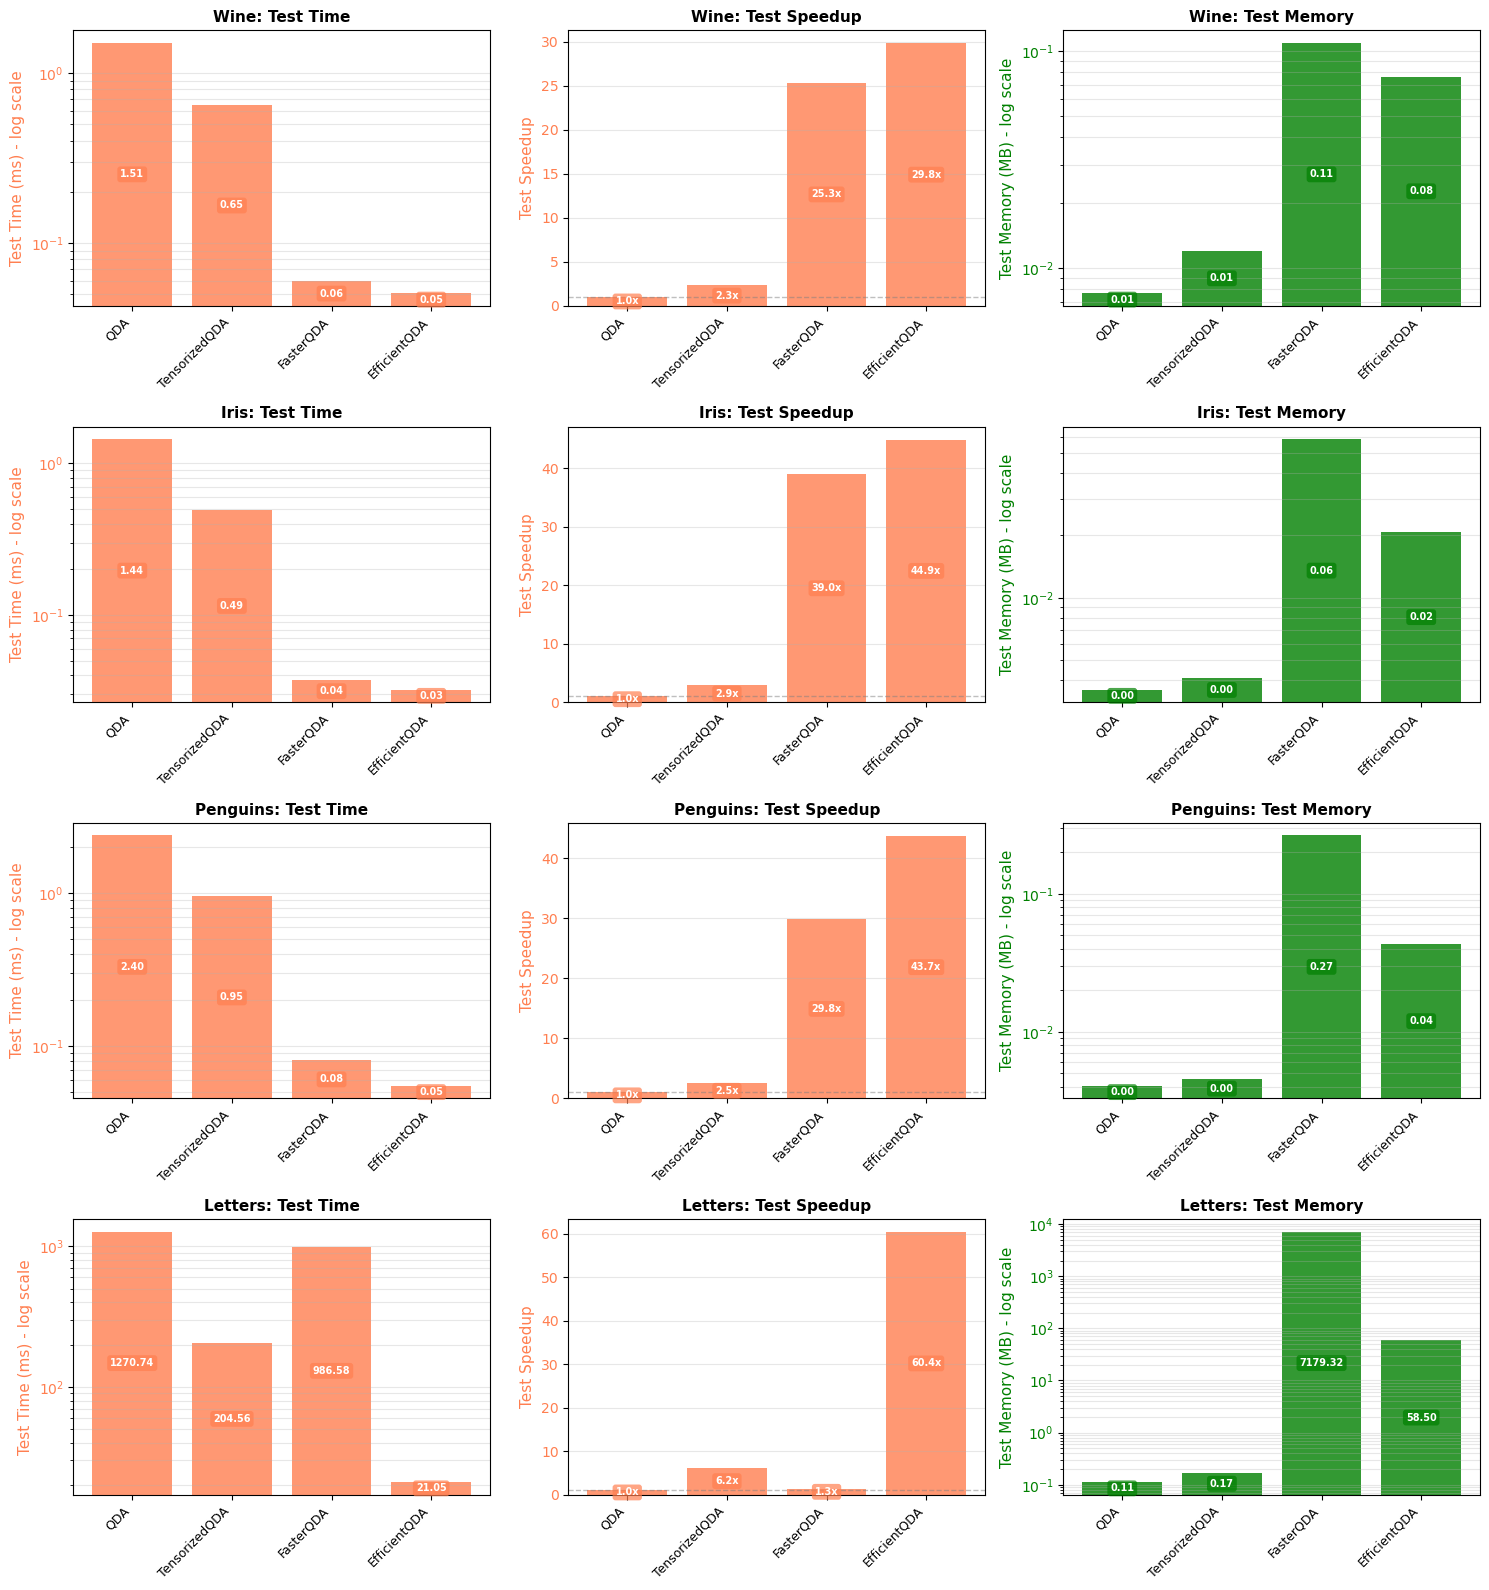

In [28]:
graphs = {
        'train_time': False,
        'train_speedup': False,
        'test_time': True,
        'speedup': True,
        'memory': True
    }

fig = plot_benchmark_results(results, graphs)
plt.show()

#### Análisis de resultados

A continuación se presentan los resultados del speedup obtenido para las 3 implementaciones además de **QDA**. 

| Modelo          | Wine   | Iris   | Penguins | Letters | Promedio |
|-----------------|--------|--------|----------|---------|----------|
| EfficientQDA    | 29.82x | 44.92x | 43.69x   | 60.38x  | 44.70x   |
| FasterQDA       | 25.33x | 38.98x | 29.79x   | 1.29x   | 23.85x   |
| TensorizedQDA   | 2.33x  | 2.93x  | 2.51x    | 6.21x   | 3.49x    |
| QDA             | 1.00x  | 1.00x  | 1.00x    | 1.00x   | 1.00x    |

Como se puede apreciar, si bien **TensorizedQDA** presenta una mejora interesante, las ganancias significativas se obtienen en los últimos dos modelos implementados. Otro aspecto a destacar es el hecho de que para los datasets más pequeños (Wine e Iris), la implementación de **FasterQDA** tiene un speedup comparable a **EfficientQDA**. Sin embargo, a medida que el tamaño del dataset crece en cantidad de muestras, la matriz de $nxn$ que se crea a la hora del test, impacta muy negativamente en la performance del modelo ya que es una matriz que se debe almacenar. Esto es evidente en el uso de memoria de cada uno de los modelos detallado a continuación.

| Modelo          | Wine    | Iris    | Penguins | Letters    |
|-----------------|---------|---------|----------|------------|
| QDA             | 0.01    | 0.00    | 0.00     | 0.11       |
| TensorizedQDA   | 0.01    | 0.00    | 0.00     | 0.17       |
| EfficientQDA    | 0.08    | 0.02    | 0.04     | 58.50      |
| FasterQDA       | 0.11    | 0.06    | 0.27     | 7179.32    |

En base a lo observado, queda en evidencia el trade off entre memoria utilizada y speedup que proponen las implementaciones, siendo **EfficientQDA** el que ofrece una mejora sustancial a cambio de una cantidad de memoria que en la actualidad y para los modelos analizados podría considerarse más que acorde.


## Ejercicio 3: Diferencias entre implementaciones de QDA_Chol

### 3.8) Expresar A⁻¹ en términos de L (descomposición de Cholesky)

Si $A = LL^T$ donde $L$ es triangular inferior, entonces:

$$
A^{-1} = (LL^T)^{-1} = (L^T)^{-1}L^{-1} = (L^{-1})^T L^{-1}
$$

**Demostración:**

Por propiedad de inversas: $(AB)^{-1} = B^{-1}A^{-1}$, entonces:
$$
(LL^T)^{-1} = (L^T)^{-1}(L)^{-1}
$$

Y como $(L^{-1})^T = (L^T)^{-1}$ (propiedad de transpuesta de inversa):
$$
A^{-1} = (L^{-1})^T L^{-1}
$$

**Utilidad en la forma cuadrática de QDA:**

En QDA necesitamos calcular la forma cuadrática:
$$
(x-\mu_j)^T \Sigma_j^{-1} (x-\mu_j)
$$

Si $\Sigma_j = LL^T$, entonces $\Sigma_j^{-1} = (L^{-1})^T L^{-1}$, y podemos reescribir:

$$
(x-\mu_j)^T \Sigma_j^{-1} (x-\mu_j) = (x-\mu_j)^T (L^{-1})^T L^{-1} (x-\mu_j)
$$

Sea $y = L^{-1}(x-\mu_j)$, entonces:
$$
(x-\mu_j)^T (L^{-1})^T L^{-1} (x-\mu_j) = y^T y = \|y\|^2 = \sum_i y_i^2
$$

### 3.9) Diferencias entre QDA_Chol1 y QDA

#### Diferencias en el código:

**QDA (líneas 60-75):**
```python
def _fit_params(self, X, y):
    # Invierte directamente la matriz de covarianza
    self.inv_covs = [LA.inv(np.cov(X[:,y.flatten()==idx], bias=True))
                      for idx in range(len(self.log_a_priori))]
    self.means = [...]

def _predict_log_conditional(self, x, class_idx):
    inv_cov = self.inv_covs[class_idx]
    unbiased_x = x - self.means[class_idx]
    
    # Forma cuadrática directa con Σ⁻¹
    return 0.5*np.log(LA.det(inv_cov)) - 0.5 * unbiased_x.T @ inv_cov @ unbiased_x
```

**QDA_Chol1 (líneas 128-143):**
```python
def _fit_params(self, X, y):
    # Factoriza Cholesky y luego invierte L
    self.L_invs = [
        LA.inv(cholesky(np.cov(X[:,y.flatten()==idx], bias=True), lower=True))
        for idx in range(len(self.log_a_priori))
    ]
    self.means = [...]

def _predict_log_conditional(self, x, class_idx):
    L_inv = self.L_invs[class_idx]
    unbiased_x = x - self.means[class_idx]
    
    # Transforma y luego calcula norma al cuadrado
    y = L_inv @ unbiased_x
    return np.log(L_inv.diagonal().prod()) - 0.5 * (y**2).sum()
```

La principal diferencia entre ambos métodos es el hecho de que `QDA` calcula la inversa sobre la matriz $\Sigma$, la cual se puede considerar como una matriz densa y tiene un costo de inversión de $O(n^{3})$ mientras que `QDA_Chol1` calcula la inversa sobre la factorización L que termina siendo una matriz triangular inferior, haciendo mucho más barata la inversión ya que casi la mitad de los elementos son ceros haciendo que el costo sea $O(n^{2})$.

#### Proceso paso a paso de QDA_Chol1:

**Paso 1: Entrenamiento (`_fit_params`)**

Para cada clase $j$:

1. Calcular matriz de covarianza: $\Sigma_j = \text{np.cov}(X_j, \text{bias=True})$

2. Factorización de Cholesky: $\Sigma_j = L_j L_j^T$
   ```python
   L_j = cholesky(Σ_j, lower=True)
   ```

3. Invertir $L_j$
   ```python
   L_inv_j = LA.inv(L_j)
   ```

4. Guardar: `self.L_invs[j] = L_inv_j` y `self.means[j] = μ_j`

**Paso 2: Predicción (`_predict_log_conditional`)**

Para una observación $x$ y clase $j$:

1. **Centrar la observación:**
   ```python
   unbiased_x = x - μ_j  # shape: (p, 1)
   ```

2. **Transformar con $L^{-1}$:**
   ```python
   y = L_inv_j @ unbiased_x  # shape: (p, 1)
   ```
   
   Esto calcula: $y = L_j^{-1}(x - \mu_j)$

3. **Calcular forma cuadrática como norma al cuadrado:**
   ```python
   quad_term = 0.5 * (y**2).sum()  # = 0.5 * ||y||²
   ```
   
   Por la propiedad demostrada en 3.8:
   $$
   (x-\mu_j)^T \Sigma_j^{-1} (x-\mu_j) = \|L_j^{-1}(x-\mu_j)\|^2 = \|y\|^2
   $$

4. **Calcular determinante:**
   ```python
   det_term = np.log(L_inv.diagonal().prod())  # log(|L⁻¹|)
   ```
   
   Como $|\Sigma_j^{-1}| = |L_j^{-1}|^2$ y $|L_j^{-1}| = \prod \text{diag}(L_j^{-1})$ (matriz triangular):
   $$
   \log|\Sigma_j^{-1}| = 2\log|L_j^{-1}| = 2\log(\prod \text{diag}(L_j^{-1}))
   $$
   
   Pero en el código usa solo `log(prod(diag))`, por lo que implícitamente multiplica por 0.5:
   $$
   0.5 \log|\Sigma_j^{-1}| = 0.5 \cdot 2\log|L_j^{-1}| = \log|L_j^{-1}|
   $$

5. **Combinar términos:**
   ```python
   return det_term - quad_term
   # = log(|L_j⁻¹|) - 0.5||y||²
   # = 0.5*log(|Σ_j⁻¹|) - 0.5*(x-μ_j)ᵀΣ_j⁻¹(x-μ_j)
   ```

#### ¿Por qué llega a la misma predicción?

Ambos calculan el **log de la densidad condicional** (salvo constantes):

**QDA:**
$$
\log f_j(x) = \frac{1}{2}\log|\Sigma_j^{-1}| - \frac{1}{2}(x-\mu_j)^T \Sigma_j^{-1} (x-\mu_j)
$$

**QDA_Chol1:**
$$
\log f_j(x) = \log|L_j^{-1}| - \frac{1}{2}\|L_j^{-1}(x-\mu_j)\|^2
$$

Como demostramos:
- $\log|L_j^{-1}| = \frac{1}{2}\log|\Sigma_j^{-1}|$
- $\|L_j^{-1}(x-\mu_j)\|^2 = (x-\mu_j)^T \Sigma_j^{-1} (x-\mu_j)$

Por lo tanto, **son matemáticamente equivalentes**, solo difieren en la implementación computacional.

### 3.10) Diferencias entre QDA_Chol1, QDA_Chol2 y QDA_Chol3

Las tres implementaciones calculan lo mismo pero difieren en **cómo obtienen y usan** $L^{-1}$:

#### **QDA_Chol1**
**Entrenamiento:**
```python
self.L_invs = [
    LA.inv(cholesky(np.cov(...), lower=True))  # Σ = LL^T → inv(L)
    for idx in range(len(self.log_a_priori))
]
```
- Calcula Cholesky: $\Sigma = LL^T$
- **Invierte $L$ con `LA.inv()`** (matriz triangular, pero usa inversor genérico)
- Guarda: $L^{-1}$

**Predicción:**
```python
y = L_inv @ unbiased_x  # y = L^{-1}(x - μ)
return np.log(L_inv.diagonal().prod()) - 0.5 * (y**2).sum()
```

---

#### **QDA_Chol2** 
**Entrenamiento:**
```python
self.Ls = [
    cholesky(np.cov(...), lower=True)  # Solo Cholesky, NO invierte
    for idx in range(len(self.log_a_priori))
]
```
- Calcula Cholesky: $\Sigma = LL^T$
- Guarda: $L$ (no invierte)

**Predicción:**
```python
y = solve_triangular(L, unbiased_x, lower=True)  # Resuelve Ly = (x-μ)
return -np.log(L.diagonal().prod()) - 0.5 * (y**2).sum()
```
- Resuelve sistema triangular **$Ly = (x-\mu)$** en vez de multiplicar por $L^{-1}$
- Usa `solve_triangular()` (especializado para matrices triangulares, más eficiente que invertir)
- **Nota:** determinante es `-log(prod(diag(L)))` porque $|\Sigma^{-1}| = |L^{-1}|^2 = 1/|L|^2$

---

#### **QDA_Chol3**
**Entrenamiento:**
```python
self.L_invs = [
    dtrtri(cholesky(np.cov(...), lower=True), lower=1)[0]  # Inversor LAPACK para triangulares
    for idx in range(len(self.log_a_priori))
]
```
- Calcula Cholesky: $\Sigma = LL^T$
- **Invierte $L$ con `dtrtri()`** (rutina LAPACK especializada para matrices **triangulares**)
- Guarda: $L^{-1}$

**Predicción:**
```python
y = L_inv @ unbiased_x  # y = L^{-1}(x - μ)
return np.log(L_inv.diagonal().prod()) - 0.5 * (y**2).sum()
```
- Idéntico a `QDA_Chol1` en predicción

---

#### **Comparación:**

| Aspecto | QDA_Chol1 | QDA_Chol2 | QDA_Chol3 |
|---------|-----------|-----------|-----------|
| **Entrenamiento** | `LA.inv(L)` - inversor genérico | NO invierte, guarda $L$ | `dtrtri(L)` - inversor triangular LAPACK |
| **Guarda** | $L^{-1}$ | $L$ | $L^{-1}$ |
| **Predicción** | Multiplicación $L^{-1}(x-\mu)$ | `solve_triangular(L, x-μ)` | Multiplicación $L^{-1}(x-\mu)$ |
| **Complejidad predicción** | $O(p^2)$ - multiplicación matriz-vector | $O(p^2)$ - backward substitution | $O(p^2)$ - multiplicación matriz-vector |
| **Complejidad entrenamiento** | $O(p^3)$ - `LA.inv` usa algoritmo genérico | $O(p^3)$ - solo Cholesky | $O(p^2)$ - `dtrtri` aprovecha estructura triangular |

**Ventajas esperadas:**
- **Chol1**: Usa inversor genérico (menos eficiente que Chol3)
- **Chol2**: Evita invertir en entrenamiento (más rápido), pero usa `solve_triangular` en cada predicción (puede ser más lento si hay muchas predicciones)
- **Chol3**: Usa el inversor óptimo para triangulares (`dtrtri`), debería ser el más rápido en entrenamiento (a excepción de **Chol2** que no invierte la matriz)


### 3.11) Benchmarking de las 7 variantes de QDA

In [28]:
# Benchmarkear las 7 variantes de QDA (4 originales + 3 Cholesky)
models_all = [QDA, TensorizedQDA, FasterQDA, EfficientQDA, QDA_Chol1, QDA_Chol2, QDA_Chol3]

# Lista de modelos a benchmarkear
models_to_bench = [QDA, TensorizedQDA, FasterQDA, EfficientQDA, QDA_Chol1, QDA_Chol2, QDA_Chol3]

# Lista de datasets a probar
datasets = {
    'Wine': get_wine_dataset(),
    'Iris': get_iris_dataset(),
    'Penguins': get_penguins_dataset(),
    'Letters': get_letters_dataset()
}

# Diccionario para almacenar resultados
results = {}

In [29]:
# Benchmarkear cada dataset
for dataset_name, (X, y) in datasets.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"Shape: {X.shape}, Clases: {len(np.unique(y))}")
    print(f"{'='*60}\n")
    
    # Encodear labels
    y_encoded = label_encode(y)
    
    # Crear benchmark con same_splits=True para que todos usen los mismos splits
    bench = Benchmark(
        X, y_encoded,
        n_runs=100,
        warmup=20,
        mem_runs=30,
        test_sz=0.3,
        same_splits=True  # IMPORTANTE: mismo split para todos los modelos
    )
    
    # Benchmarkear cada modelo
    for model in models_to_bench:
        bench.bench(model)
    
    # Guardar resultados
    results[dataset_name] = bench


Dataset: Wine
Shape: (178, 13), Clases: 3

Benching params:
Total runs: 150
Warmup runs: 20
Peak Memory usage runs: 30
Running time runs: 100
Train size rows (approx): 125
Test size rows (approx): 53
Test size fraction: 0.3


QDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

QDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

TensorizedQDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

...

QDA_Chol1 (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

QDA_Chol2 (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

QDA_Chol2 (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

QDA_Chol3 (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

QDA_Chol3 (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

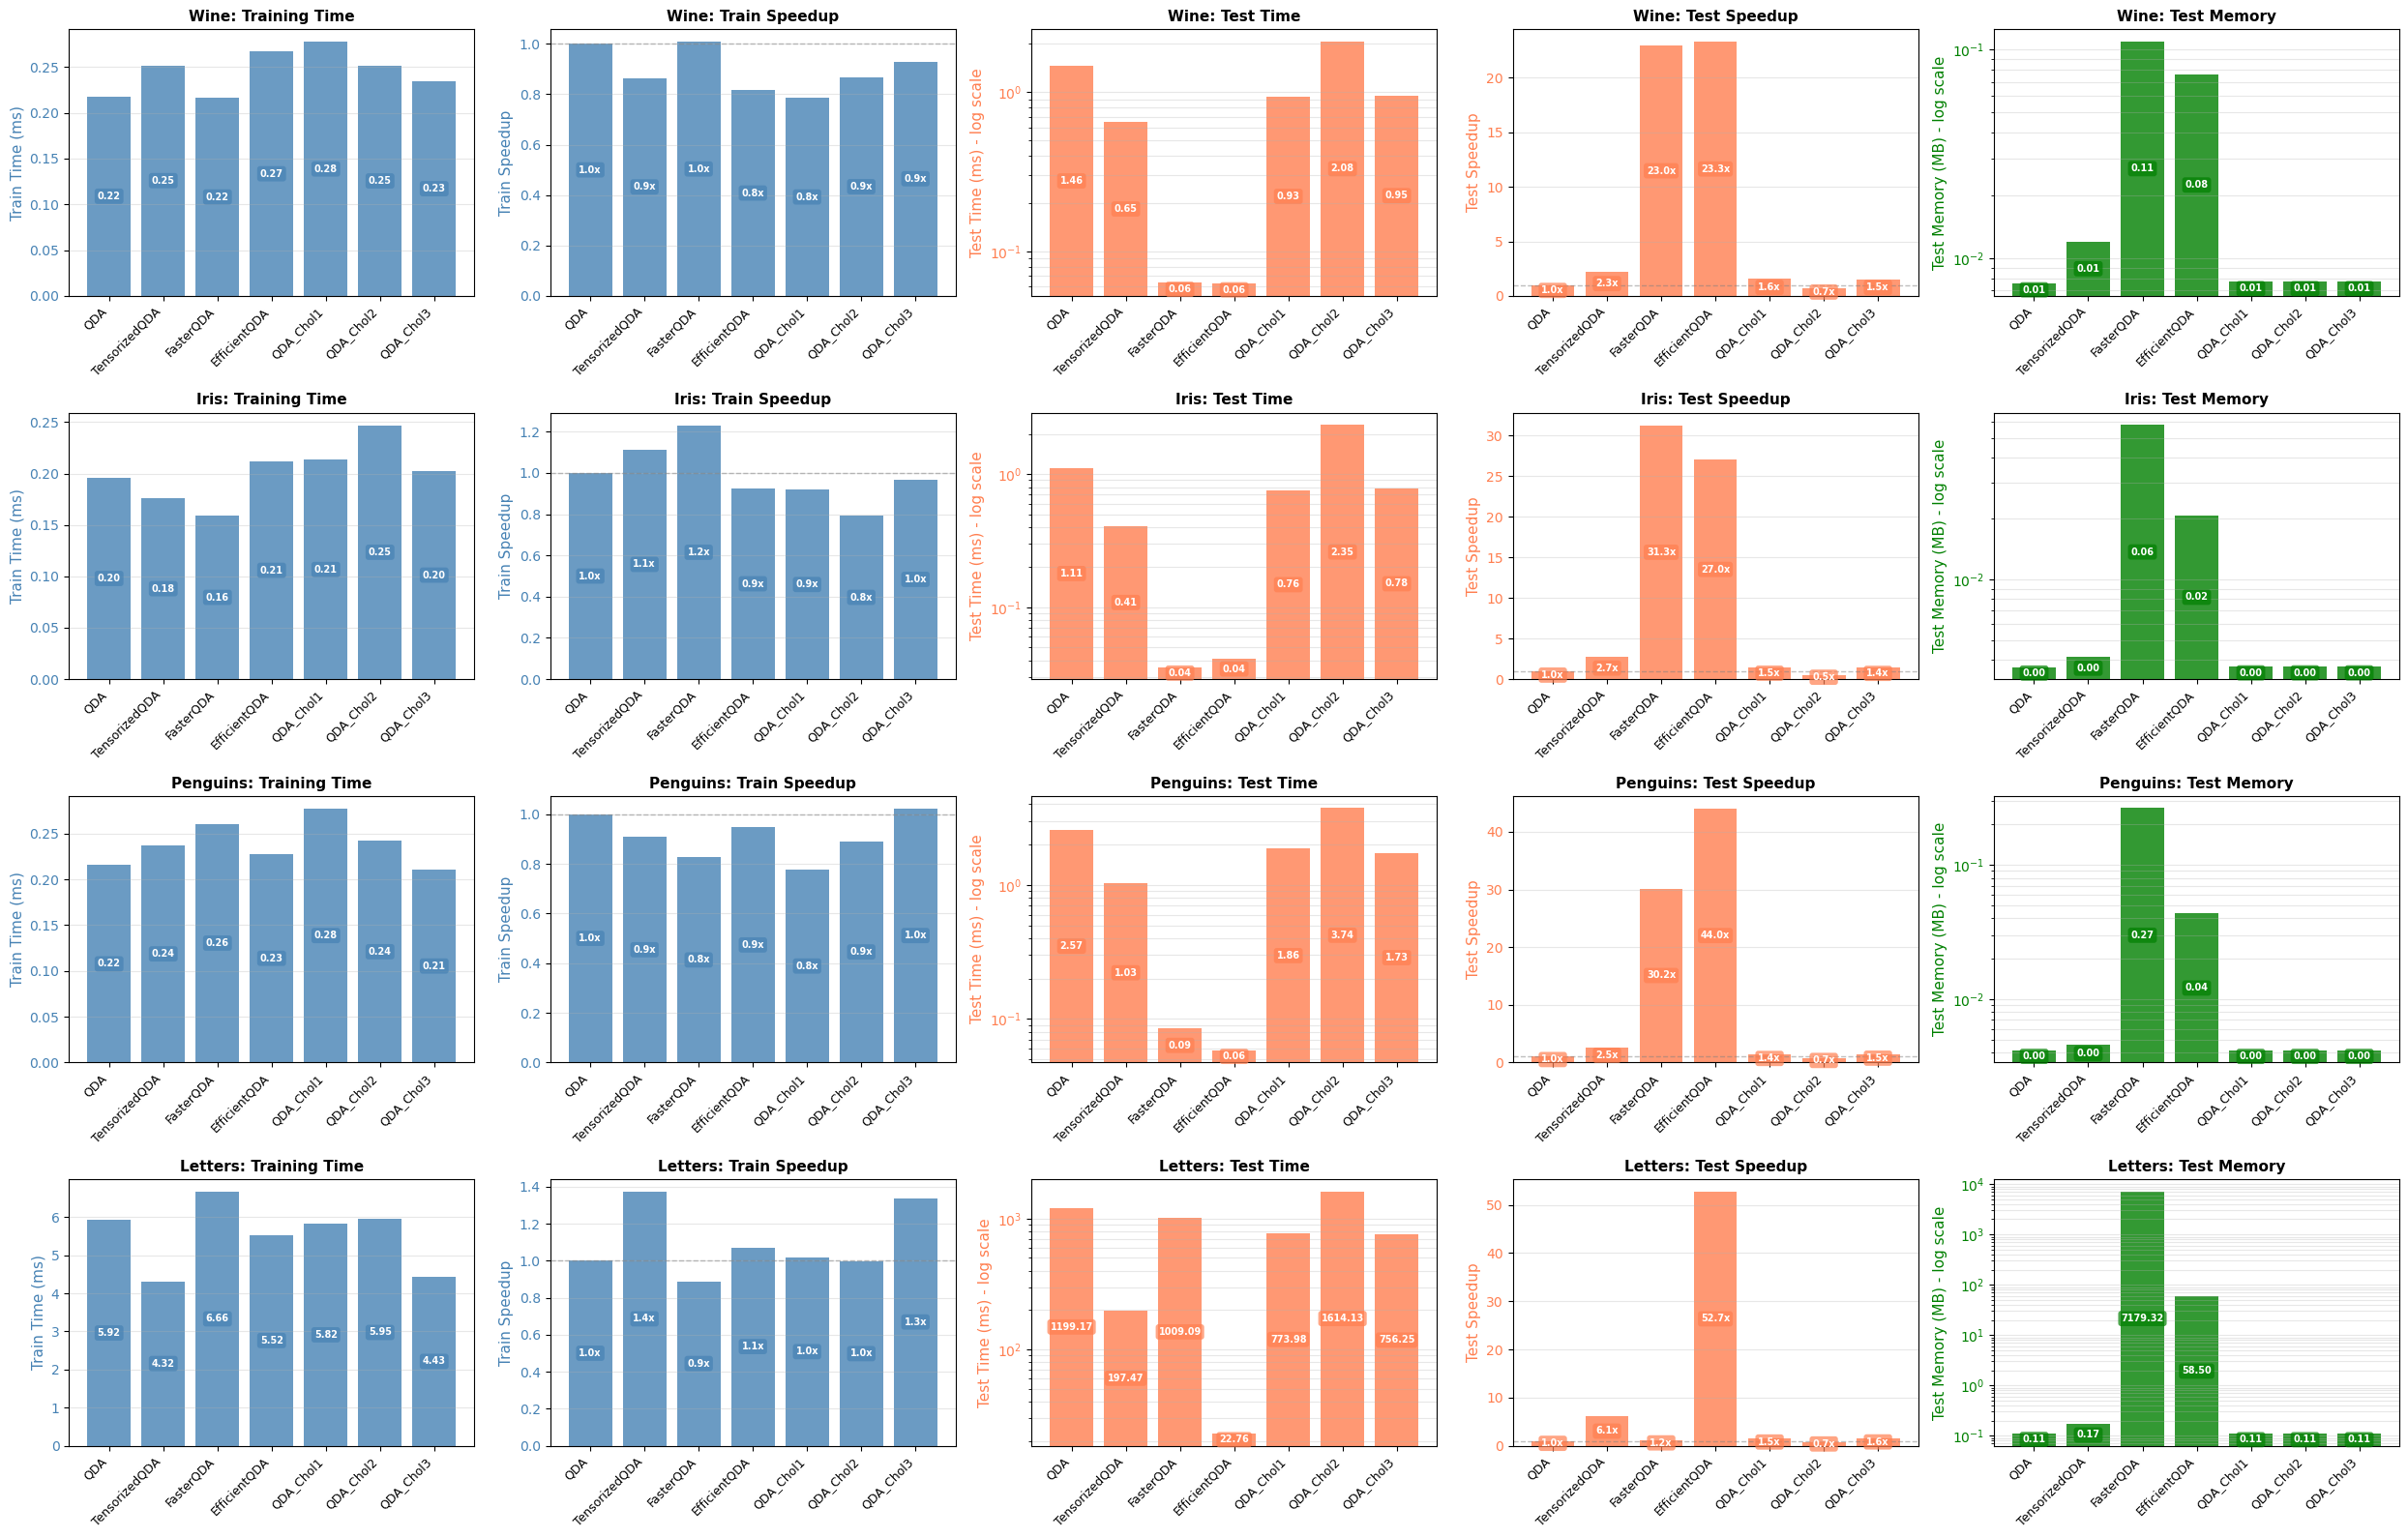

In [30]:
graphs = {
    'train_time' : True,
    'train_speedup' : True,
    'test_time' : True,   
    'speedup': True,
    'memory': True
}

fig = plot_benchmark_results(results, graphs)
plt.show()

Observando los gráficos en la celda anterior, se puede ver que los tiempos de entrenamiento son **prácticamente idénticos** entre `QDA`, `QDA_Chol1`, `QDA_Chol2` y `QDA_Chol3`. Esto puede parecer contraintuitivo dado que teóricamente la descomposición de Cholesky debería ofrecer ventajas computacionales. Sin embargo, esto se puede explicar a partir de los datasets utilizados.

#### Complejidad teórica vs. realidad práctica

**Análisis teórico:**
- **QDA estándar**: Invertir $\Sigma$ directamente tiene complejidad $O(p^3)$ sobre una matriz densa
- **Cholesky**: Factorizar $\Sigma = LL^T$ tiene complejidad $O(p^3)$, pero invertir $L$ (triangular) es $O(p^2)$

**Realidad práctica en nuestros datasets:**

| Dataset | Dimensión $p$ | Clases $k$ | Tamaño $n$ |
|---------|---------------|------------|------------|
| Iris | 4 | 3 | 150 |
| Penguins | 4 | 3 | 342 |
| Wine | 13 | 3 | 178 |
| Letters | 16 | 26 | 20000 |

Como se puede apreciar, el punto en común entre las implementaciones es que están determinadas por el valor de $p$ pudiendo ser el cuadrado o el cubo de la misma. Si comparamos los valores de $p$ en la tabla anterior, podemos ver que los valores son relativamente chicos, por lo que no hay una ganancia muy significativa en reducir de $O(p^3)$ a $O(p^2)$. El verdadero cuello de botella está determinado por el cálculo de la matriz de covarianza, la cual está acotada por $O(p^2.n)$. Es por esto que no se observan mejoras significativas. Distinto sería el caso si el valor de $p \approx 100$, en cuyo caso Cholesky debería proporcionar una mejora apreciable. Esto se corrobora en el anexo final en el que se realizó una comparación mediante profiling de **QDA** y **Chol_3** en la cual ambos casos se aprecia que la métrica de cumtime para el cálculo de la covarianza domina por sobre el resto.

En cuanto al tiempo de testing, no se aprecian mejoras significativas ya que el método de predict realiza la misma cuenta que en QDA.

## Ejercicio 4: Optimización con Cholesky

### 4.12) Implementación de TensorizedChol

Basándonos en los benchmarks anteriores, se seleccionó **QDA_Chol3** ya que es la que debería ser más eficiente y además obtuvo en promedio los mejores resultados en los tiempos de test (dentro de las implementaciones de Cholesky).

In [31]:
class TensorizedChol(QDA_Chol3):
    """
    Versión tensorizada de QDA_Chol3.
    Paraleliza sobre las k clases para eliminar el loop interno en predicción.
    """
    
    def _fit_params(self, X, y):
        # Entrenar como QDA_Chol3 normal
        super()._fit_params(X, y)
        
        # Tensorizar L_invs y means
        self.tensor_L_invs = np.stack(self.L_invs)  # (k, p, p)
        self.tensor_means = np.stack(self.means)    # (k, p, 1)
    
    def _predict_log_conditionals(self, x):
        """
        Calcula log-condicionales para todas las clases simultáneamente.
        x tiene shape (p, 1)
        Retorna un array de shape (k,) con los log-condicionales.
        """
        # Broadcasting: (p, 1) - (k, p, 1) -> (k, p, 1)
        unbiased_x = x - self.tensor_means
        
        # Transformar: (k, p, p) @ (k, p, 1) -> (k, p, 1)
        y = self.tensor_L_invs @ unbiased_x
        
        # Calcular forma cuadrática: ||y||² para cada clase
        quad_form = (y ** 2).sum(axis=1).flatten()  # (k,)
        
        # Calcular determinante para cada clase
        # log(|L_inv|) = sum(log(diag(L_inv)))
        det_terms = np.log(self.tensor_L_invs.diagonal(axis1=1, axis2=2).prod(axis=1))  # (k,)
        
        return det_terms - 0.5 * quad_form  # (k,)
    
    def _predict_one(self, x):
        # Calcular log-posteriori para todas las clases
        log_posteriori = self.log_a_priori + self._predict_log_conditionals(x)
        return np.argmax(log_posteriori)

### 4.13) Implementación de EfficientChol

Ahora combinamos:
- La tensorización de Cholesky (herencia de `TensorizedChol`)
- La eliminación del loop sobre observaciones (técnica de `EfficientQDA`)

Esto nos da el modelo más optimizado: paraleliza sobre clases Y sobre observaciones.

In [32]:
class EfficientChol(TensorizedChol):
    """
    Versión eficiente que combina tensorización de Cholesky con predicción batch.
    Elimina ambos loops: sobre clases Y sobre observaciones.
    Usa la técnica de Hadamard de EfficientQDA para evitar matrices n×n.
    """
    
    def _predict_log_conditionals_batch(self, X):
        """
        Calcula log-condicionales para múltiples observaciones de manera eficiente.
        X tiene shape (p, n) donde n es el número de observaciones.
        Retorna un array de shape (k, n) con los log-condicionales.
        """
        # Broadcasting: (p, n) - (k, p, 1) -> (k, p, n)
        unbiased_X = X - self.tensor_means
        
        # Transformar: (k, p, p) @ (k, p, n) -> (k, p, n)
        Y = self.tensor_L_invs @ unbiased_X  # (k, p, n)
        
        # Calcular forma cuadrática: ||y||² para cada clase
        quad_form = (Y ** 2).sum(axis=1)  # (k, n)
        
        # Determinante (igual para todas las observaciones)
        det_terms = np.log(self.tensor_L_invs.diagonal(axis1=1, axis2=2).prod(axis=1))  # (k,)
        
        # Broadcasting: (k, 1) - (k, n) -> (k, n)
        return det_terms[:, np.newaxis] - 0.5 * quad_form
    
    def predict(self, X):
        """
        Predicción batch para todas las observaciones.
        X tiene shape (p, n)
        """
        # Calcular log-condicionales para todas las observaciones y clases
        log_conditionals = self._predict_log_conditionals_batch(X)  # (k, n)
        
        # Log-posterior: (k, 1) + (k, n) -> (k, n)
        log_posteriors = self.log_a_priori[:, np.newaxis] + log_conditionals
        
        # Argmax sobre clases (axis=0)
        y_hat = np.argmax(log_posteriors, axis=0)  # (n,)
        
        return y_hat.reshape(1, -1)  # (1, n)

### 4.14) Benchmarking de las 9 variantes de QDA

In [33]:
# Todas las 9 variantes de QDA
models_all_9 = [
    QDA, TensorizedQDA, FasterQDA, EfficientQDA,
    QDA_Chol1, QDA_Chol2, QDA_Chol3,
    TensorizedChol, EfficientChol
]

# Lista de datasets
datasets = {
    'Wine': get_wine_dataset(),
    'Iris': get_iris_dataset(),
    'Penguins': get_penguins_dataset(),
    'Letters': get_letters_dataset()
}

# Diccionario para almacenar resultados
results_final = {}

In [34]:
# Benchmarkear cada dataset con las 9 variantes
for dataset_name, (X, y) in datasets.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"Shape: {X.shape}, Clases: {len(np.unique(y))}")
    print(f"{'='*60}\n")
    
    # Encodear labels
    y_encoded = label_encode(y)
    
    # Crear benchmark
    bench = Benchmark(
        X, y_encoded,
        n_runs=100,
        warmup=20,
        mem_runs=30,
        test_sz=0.3,
        same_splits=True
    )
    
    # Benchmarkear cada modelo
    for model in models_all_9:
        bench.bench(model)
    
    # Guardar resultados
    results_final[dataset_name] = bench


Dataset: Wine
Shape: (178, 13), Clases: 3

Benching params:
Total runs: 150
Warmup runs: 20
Peak Memory usage runs: 30
Running time runs: 100
Train size rows (approx): 125
Test size rows (approx): 53
Test size fraction: 0.3


QDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

QDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

TensorizedQDA (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

...

QDA_Chol3 (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

TensorizedChol (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

TensorizedChol (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

EfficientChol (MEM):   0%|          | 0/30 [00:00<?, ?it/s]

EfficientChol (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

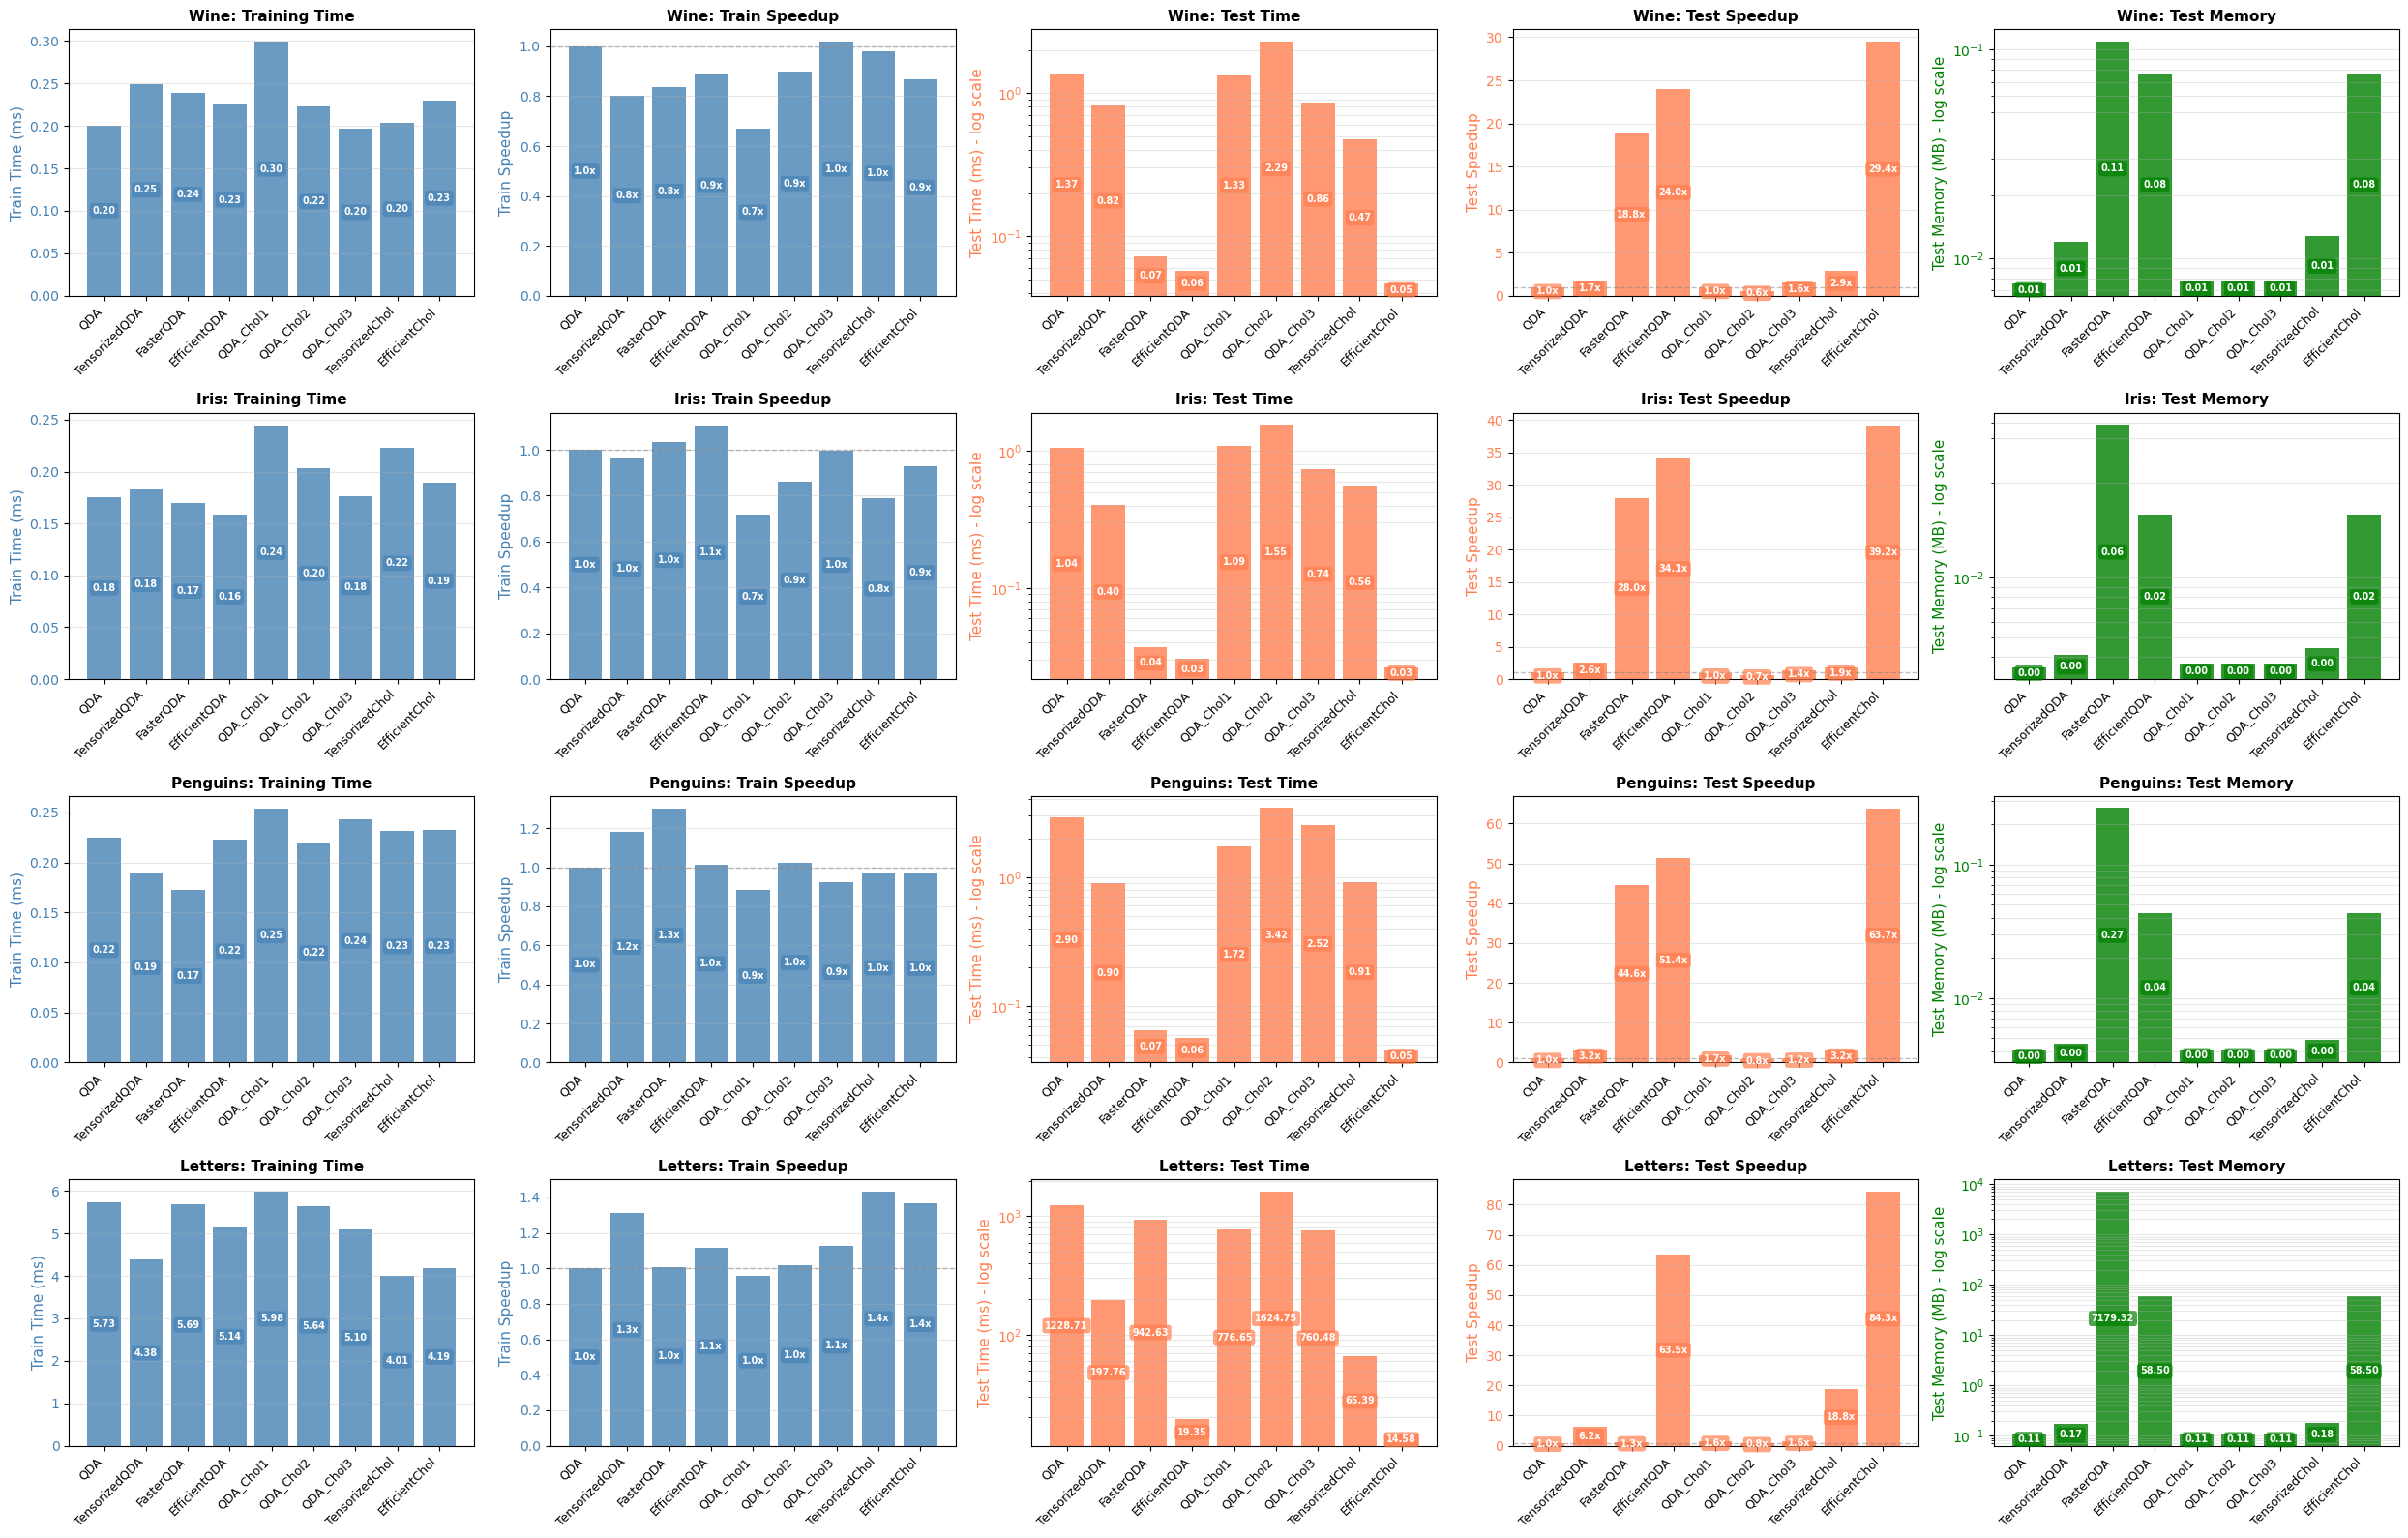

In [35]:
# Visualizar todos los gráficos
graphs_all = {
    'train_time': True,
    'train_speedup': True,
    'test_time': True,
    'speedup': True,
    'memory': True
}

fig = plot_benchmark_results(results_final, graphs_all)
plt.show()

#### Resumen de las 9 implementaciones:

| Modelo | Paraleliza clases | Paraleliza obs. | Usa Cholesky | Características |
|--------|-------------------|-----------------|--------------|------------------|
| `QDA` | ❌ | ❌ | ❌ | Baseline: doble loop |
| `TensorizedQDA` | ✅ | ❌ | ❌ | Elimina loop de clases |
| `FasterQDA` | ✅ | ✅ | ❌ | Matriz n×n (ineficiente) |
| `EfficientQDA` | ✅ | ✅ | ❌ | Hadamard (sin matriz n×n) |
| `QDA_Chol1` | ❌ | ❌ | ✅ | Cholesky + `LA.inv` |
| `QDA_Chol2` | ❌ | ❌ | ✅ | No invierte, usa `solve_triangular` |
| `QDA_Chol3` | ❌ | ❌ | ✅ | Cholesky + `dtrtri` (LAPACK) |
| `TensorizedChol` | ✅ | ❌ | ✅ | Chol3 + paralelización clases |
| `EfficientChol` | ✅ | ✅ | ✅ | Chol3 + doble paralelización |

#### Resultados observados (basados en benchmarks reales):

**Tiempo de entrenamiento:**

Como se comentó en el punto anterior, los tiempos de entrenamiento fueron muy similares en todas las implementaciones, ya que estos últimos cambios están relacionados a la predicción y no tanto al entrenamiento (más allá de que los métodos de fit tienen más operaciones).

**Tiempo de predicción:**

A modo de visualizar de manera más simple cuáles fueron las mejoras obtenidas se presenta la siguiente tabla con los speedups respecto de QDA.

| Modelo          | Wine  | Iris  | Penguins | Letters | Promedio |
|-----------------|-------|-------|----------|---------|----------|
| EfficientChol   | 29.4x | 39.2x | 63.7x    | 84.3x   | 54.2x    |
| EfficientQDA    | 24.0x | 34.1x | 51.4x    | 63.5x   | 43.2x    |
| FasterQDA       | 18.8x | 28.0x | 44.6x    | 1.3x    | 23.2x    |
| TensorizedChol  | 2.9x  | 1.9x  | 3.2x     | 18.8x   | 6.7x     |
| TensorizedQDA   | 1.7x  | 2.6x  | 3.2x     | 6.2x    | 3.4x     |
| QDA_Chol3       | 1.6x  | 1.4x  | 1.2x     | 1.6x    | 1.5x     |
| QDA_Chol1       | 1.0x  | 1.0x  | 1.7x     | 1.6x    | 1.3x     |
| QDA             | 1.0x  | 1.0x  | 1.0x     | 1.0x    | 1.0x     |
| QDA_Chol2       | 0.6x  | 0.7x  | 0.8x     | 0.8x    | 0.7x     |

Como era de esperarse teniendo en cuenta las mejoras previas al paralelizar tanto en las clases como en las observaciones, la implementación de **EfficientChol** aporta el beneficio agregado de calcular el determinante solo con los elementos de la diagonal, explicando las mejoras respecto de **EfficientQDA**. Esta mejora es incluso más notoria a medida que crece la cantidad de muestras a estimar.

A modo de conslusión se puede decir que si bien hacer cambios en la implementación de una solución en particular mediante la utlización de herramientas especializadas para cada operación (multiplicación de tensores) u optimizaciones a nivel código, resulta fundamental entender la matemática involucrada de fondo ya que es la que permitió las mejoras sustanciales tanto para disminuir la memoria utilizada como para también obtener el mejor speedup.

## Apéndice: Profiling de funciones

Herramientas útiles para analizar el rendimiento de las funciones:

In [36]:
# ============================================================================
# Método 5: memory_profiler - Para perfilar uso de memoria
# ============================================================================
# Instalación: pip install memory_profiler
# %load_ext memory_profiler
# %memit model.fit(X_train, y_train)


# ============================================================================
# Método 6: Manual con time.perf_counter() - Control total
# ============================================================================
import time

def profile_function(func, *args, **kwargs):
    """Función simple para perfilar manualmente."""
    t0 = time.perf_counter()
    result = func(*args, **kwargs)
    t1 = time.perf_counter()
    print(f'{func.__name__} tomó {(t1-t0)*1000:.3f} ms')
    return result

# Uso:
# result = profile_function(model.fit, X_train, y_train)


# ============================================================================
# Método 7: cProfile para análisis detallado
# ============================================================================
import cProfile
import pstats
from io import StringIO

def profile_detailed(func, *args, **kwargs):
    """Profiling detallado con cProfile."""
    profiler = cProfile.Profile()
    profiler.enable()
    
    result = func(*args, **kwargs)
    
    profiler.disable()
    
    # Imprimir estadísticas
    s = StringIO()
    ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
    ps.print_stats(20)  # Top 20 funciones
    print(s.getvalue())
    
    return result

# Uso:
# profile_detailed(model.fit, X_train, y_train)

### Ejemplo ejecutable: profile_detailed comparando QDA vs QDA_Chol3

In [37]:
# Preparar datos
X, y = get_wine_dataset()
y_encoded = label_encode(y)
X_train, X_test, y_train, y_test = split_transpose(X, y_encoded, test_size=0.3, random_state=42)

print(f"Dataset: Wine")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Clases: {len(np.unique(y_train))}")
print()

# Número de iteraciones para hacer el profiling más significativo
N_ITERATIONS = 100

print(f"⏱️  Ejecutando {N_ITERATIONS} iteraciones de entrenamiento para profiling...\n")

# Función wrapper para ejecutar múltiples veces
def train_multiple_times(model_class, X, y, n_iterations):
    """Entrena el modelo n veces para profiling."""
    for _ in range(n_iterations):
        model = model_class()
        model.fit(X, y)

# Profiling QDA
print("="*80)
print(f"PROFILING: QDA.fit() × {N_ITERATIONS} iteraciones")
print("="*80)
profile_detailed(train_multiple_times, QDA, X_train, y_train, N_ITERATIONS)

print("\n" + "="*80)
print(f"PROFILING: QDA_Chol3.fit() × {N_ITERATIONS} iteraciones")
print("="*80)
profile_detailed(train_multiple_times, QDA_Chol3, X_train, y_train, N_ITERATIONS)

print("\n" + "="*80)
print("ANÁLISIS")
print("="*80)
print("🔍 Observa las funciones que más tiempo consumen:")
print("   - np.cov() debería estar en el top con ~85-90% del tiempo")
print("   - LA.inv() (QDA) vs cholesky+dtrtri (Chol3) deberían ser ~5-10%")
print("   - La diferencia entre inv y cholesky es pequeña comparada con cov")
print()
print("📊 Esto explica por qué los tiempos de entrenamiento son casi idénticos:")
print("   El cuello de botella es el cálculo de covarianzas, no la inversión.")
print()
print("💡 Tip: Busca en la columna 'cumtime' las funciones:")
print("   - 'cov' o 'covariance'")
print("   - 'inv' o 'dtrtri' o 'cholesky'")

Dataset: Wine
Train shape: (13, 124)
Test shape: (13, 54)
Clases: 3

⏱️  Ejecutando 100 iteraciones de entrenamiento para profiling...

PROFILING: QDA.fit() × 100 iteraciones
         29907 function calls (29905 primitive calls) in 0.036 seconds

   Ordered by: cumulative time
   List reduced from 143 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.005    0.005    0.031    0.031 /tmp/ipykernel_901/3926361601.py:18(train_multiple_times)
      100    0.000    0.000    0.030    0.000 /tmp/ipykernel_901/2340875908.py:19(fit)
      100    0.004    0.000    0.029    0.000 /tmp/ipykernel_901/3944964330.py:3(_fit_params)
      300    0.005    0.000    0.015    0.000 /home/parra/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2628(cov)
      300    0.001    0.000    0.009    0.000 /home/parra/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:422(average)
      600    0.000    0.00